# Data Exploration and Growth Phase Identification

This notebook presents an exploratory analysis of synthetic batch fermentation data. Key process variables—including biomass, substrate, and product concentrations—are visualized to understand fermentation behavior. Growth trends are further examined using semi-logarithmic biomass plots to identify the exponential growth region, providing a basis for subsequent kinetic parameter estimation.

In [1]:
import pandas as pd
df = pd.read_csv('../data/synthetic_batch_fermentation.csv')
print(df['biomass_gL'].diff().head())
print(f"Total rows: {len(df)}")

0         NaN
1    0.021449
2    0.037941
3    0.058152
4    0.058086
Name: biomass_gL, dtype: float64
Total rows: 31


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

df = pd.read_csv('../data/synthetic_batch_fermentation.csv')
df.head()

,time_h,biomass_gL,substrate_gL
0,0.000000,0.051242,10.926139
1,0.857143,0.072691,9.946889
2,1.714286,0.110632,9.362868
3,2.571429,0.168783,10.188805
4,3.428571,0.226869,9.052386


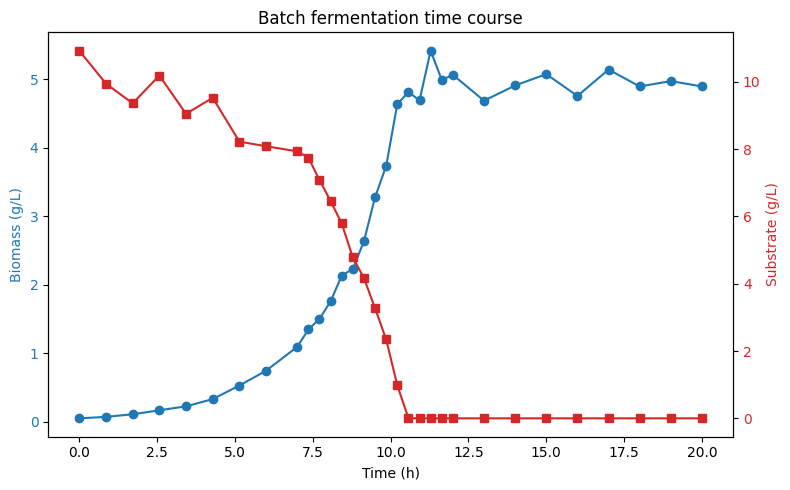

In [3]:
#  plot biomass and substrate
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(df['time_h'], df['biomass_gL'], 'o-', color='C0', label='Biomass')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Biomass (g/L)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

ax2 = ax1.twinx()
ax2.plot(df['time_h'], df['substrate_gL'], 's-', color='C3', label='Substrate')
ax2.set_ylabel('Substrate (g/L)', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')

plt.title('Batch fermentation time course')
plt.tight_layout()
plt.savefig('../figures/01_raw_data.png')
plt.show()

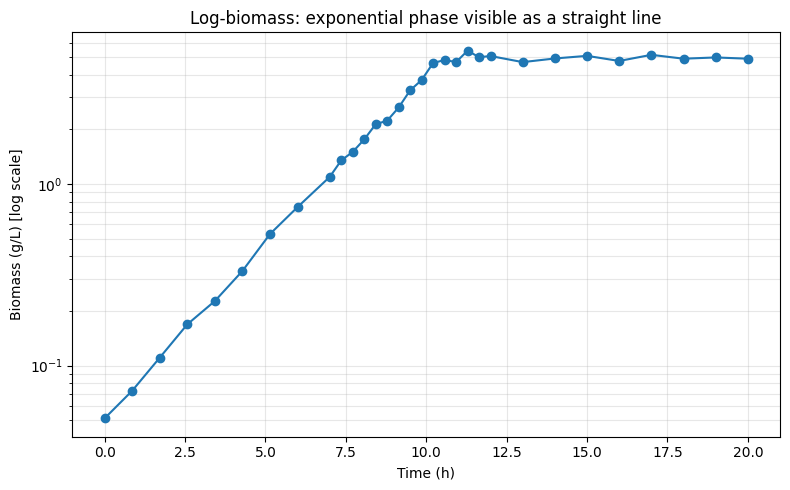

In [4]:
# log-linear plot for the exponential phase
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(df['time_h'], df['biomass_gL'], 'o-')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Biomass (g/L) [log scale]')
ax.set_title('Log-biomass: exponential phase visible as a straight line')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/02_log_biomass.png')
plt.show()
